# Phase 3 – Data Exploration & Feature Engineering
## Objectives
Analyze the collected data to understand its structure, uncover meaningful insights, and engineer useful features for modeling.

## Tasks

### 1. Exploratory Data Analysis (EDA)
- Compute descriptive statistics (mean, median, standard deviation, etc.).
- Visualize data distribution and relationships using charts (histograms, scatter plots, correlation heatmaps, box plots, etc.).
- Identify trends, outliers, anomalies, and potential issues.
### 2. Insight Extraction
- Highlight important patterns or relationships relevant to your research problem.
- Describe how these findings guide your next steps (modeling or deeper analysis).
### 3. Feature Engineering
- Create new attributes from existing raw features (e.g., ratios, aggregated variables, domain-based transformations).
- Encode categorical variables if needed.
- Scale/normalize features where appropriate.
- Justify why each engineered feature might improve performance.
### Deliverables
A concise EDA and Feature Engineering Report including:
- Key statistics and summary tables
- Visualizations with clear explanations
- A list of extracted insights
- A table of selected features with description and justification

### 1. Exploratory Data Analysis (EDA)
- Compute descriptive statistics (mean, median, standard deviation, etc.).
- Visualize data distribution and relationships using charts (histograms, scatter plots, correlation heatmaps, box plots, etc.).
- Identify trends, outliers, anomalies, and potential issues.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset

data_file = "datasets/telco_churn_clean_stage_2.csv"

df = pd.read_csv(data_file)

print("The shape of the dataset is: ", df.shape, "\n")
df.head()

The shape of the dataset is:  (5901, 21) 



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no phone service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic check,29.85,29.85,no
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one year,no,mailed check,56.95,1889.50,no
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed check,53.85,108.15,yes
3,7795-cfocw,male,0,no,no,45,no,no phone service,dsl,yes,...,yes,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75,no
4,9237-hqitu,female,0,no,no,2,yes,no,fiber optic,no,...,no,no,no,no,month-to-month,yes,electronic check,70.70,151.65,yes


### Step 2 – Basic data understanding & cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5901 non-null   object 
 1   gender            5901 non-null   object 
 2   SeniorCitizen     5901 non-null   int64  
 3   Partner           5901 non-null   object 
 4   Dependents        5901 non-null   object 
 5   tenure            5901 non-null   int64  
 6   PhoneService      5901 non-null   object 
 7   MultipleLines     5901 non-null   object 
 8   InternetService   5901 non-null   object 
 9   OnlineSecurity    5901 non-null   object 
 10  OnlineBackup      5901 non-null   object 
 11  DeviceProtection  5901 non-null   object 
 12  TechSupport       5901 non-null   object 
 13  StreamingTV       5901 non-null   object 
 14  StreamingMovies   5901 non-null   object 
 15  Contract          5901 non-null   object 
 16  PaperlessBilling  5901 non-null   object 


## Covert datatype to the proper type
AS total charges shows as an Object instead a numeric value, lets Convert TotalCharges to numeric & handle missing values

In [4]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many became NaN
df["TotalCharges"].isna().sum(), df.loc[df["TotalCharges"].isna(), ["tenure", "TotalCharges"]].head()


(np.int64(0),
 Empty DataFrame
 Columns: [tenure, TotalCharges]
 Index: [])

In [5]:
# Impute TotalCharges = 0 for tenure = 0 & NaN TotalCharges
mask_new = (df["tenure"] == 0) & (df["TotalCharges"].isna())
df.loc[mask_new, "TotalCharges"] = 0

# Confirm no more NaNs in TotalCharges
df["TotalCharges"].isna().sum()

np.int64(0)

### Step 3 – Descriptive statistics (EDA Task 1: statistics)

In [6]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

desc_stats = df[num_cols].describe().T.round(2)
desc_stats


,count,mean,std,min,25%,50%,75%,max
tenure,5901.0,32.19,24.63,0.00,9.00,28.0,55.0,72.00
MonthlyCharges,5901.0,61.85,30.32,18.25,25.60,65.8,86.7,118.75
TotalCharges,5901.0,2179.63,2231.39,18.80,367.55,1299.1,3562.5,8684.80


### Step 4 – Target variable: Churn distribution

In [7]:
churn_counts = df["churn"].value_counts()
churn_props = df["churn"].value_counts(normalize=True).round(3)

print("Counts:\n", churn_counts)
print("\nProportions:\n", churn_props)


Counts:
 churn
no     4508
yes    1393
Name: count, dtype: int64

Proportions:
 churn
no     0.764
yes    0.236
Name: proportion, dtype: float64


### Plot churn distribution

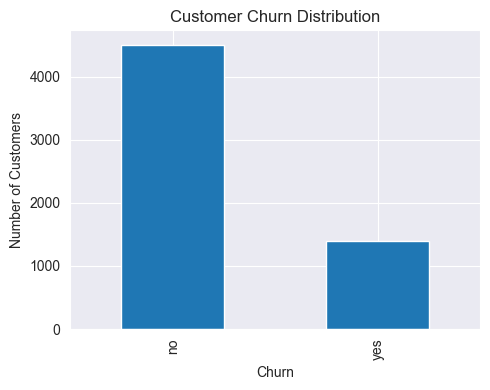

In [8]:
plt.figure(figsize=(5, 4))
churn_counts.plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## Visual 1: Churn Distribution Chart

# sns.countplot(x=y, palette="Blues")
# plt.title("Churn Distribution")
# plt.xlabel("Churn (0 = No, 1 = Yes)")
# plt.ylabel("Number of Customers")
# plt.show()

### Step 5 – Numeric relationships & correlation (EDA Task 1: relationships)
5.1 Create numeric target ChurnFlag

In [9]:
df["ChurnFlag"] = df["churn"].map({"Yes": 1, "No": 0})
df["ChurnFlag"].value_counts()


Series([], Name: count, dtype: int64)

## 5.2 Correlation matrix

In [10]:
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]
corr_matrix = df[corr_cols].corr()
corr_matrix


,tenure,MonthlyCharges,TotalCharges,ChurnFlag
tenure,1.000000,0.248766,0.814026,NaN
MonthlyCharges,0.248766,1.000000,0.662157,NaN
TotalCharges,0.814026,0.662157,1.000000,NaN
ChurnFlag,NaN,NaN,NaN,NaN


### 5.3 Simple correlation heatmap

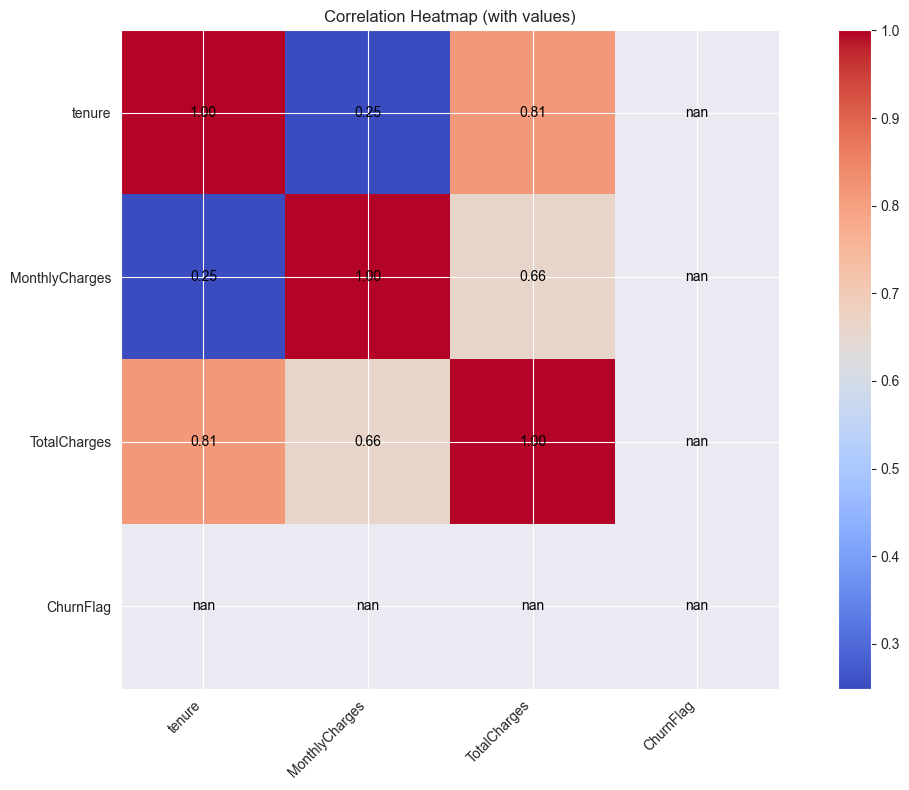

In [11]:
plt.figure(figsize=(12, 8))
im = plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")

# Add colorbar
plt.colorbar(im)

# Tick labels
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)

# Annotate values inside the heatmap
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

plt.title("Correlation Heatmap (with values)")
plt.tight_layout()
plt.show()

### Step 6 – Distribution plots & outliers (EDA Task 1: distributions)
6.1 Histograms for numeric features

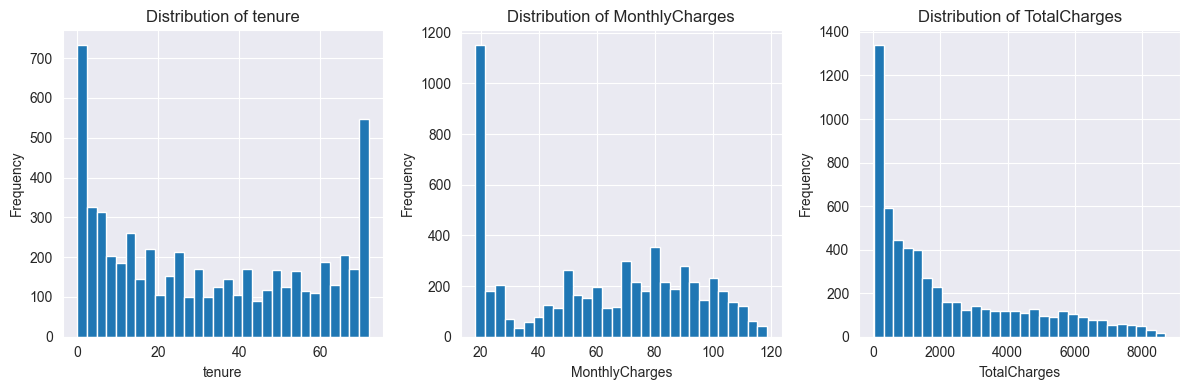

In [12]:
plt.figure(figsize=(12, 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### 6.2 Boxplots for outlier inspection

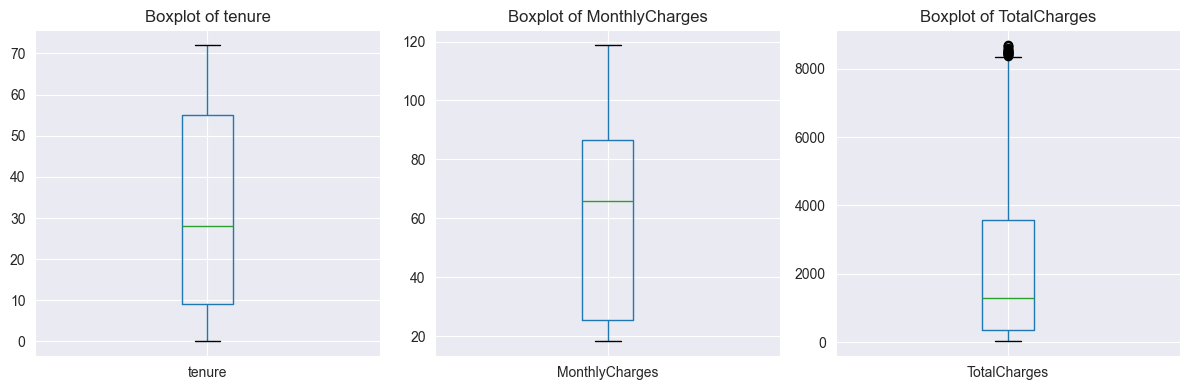

In [13]:
plt.figure(figsize=(12, 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


### Step 7 – Categorical features vs Churn (EDA Task 1 & 2)

We’ll define a helper function to compute churn rate by category.

In [14]:
def churn_rate_by(df, col):
    tmp = (
        df.groupby(col)["ChurnFlag"]
          .agg(["count", "mean"])
          .rename(columns={"mean": "ChurnRate"})
          .reset_index()
    )
    return tmp

cat_cols_to_check = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]

for col in cat_cols_to_check:
    print(f"\n=== {col} ===")
    display(churn_rate_by(df, col).round(3))



=== Contract ===


,Contract,count,ChurnRate
0,month-to-month,0,NaN
1,one year,0,NaN
2,two year,0,NaN



=== InternetService ===


,InternetService,count,ChurnRate
0,dsl,0,NaN
1,fiber optic,0,NaN
2,no,0,NaN



=== PaymentMethod ===


,PaymentMethod,count,ChurnRate
0,bank transfer (automatic),0,NaN
1,credit card (automatic),0,NaN
2,electronic check,0,NaN
3,mailed check,0,NaN



=== SeniorCitizen ===


,SeniorCitizen,count,ChurnRate
0,0,0,NaN


### Example bar chart: churn rate by Contract

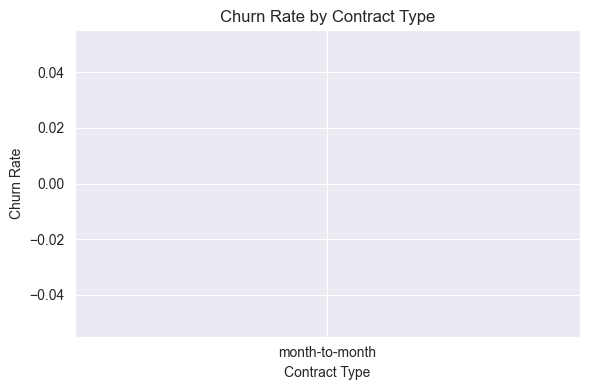

In [15]:
contract_stats = churn_rate_by(df, "Contract")

plt.figure(figsize=(6, 4))
plt.bar(contract_stats["Contract"], contract_stats["ChurnRate"])
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()


### Step 8 – Feature Engineering (Task 3)

Now we create new features, encode categoricals, and prepare a modeling-ready dataset.

8.1 Tenure bands

In [16]:
def tenure_band(t):
    if t <= 6:
        return "0-6"
    elif t <= 12:
        return "7-12"
    elif t <= 24:
        return "13-24"
    elif t <= 48:
        return "25-48"
    else:
        return "49+"

df["TenureBand"] = df["tenure"].apply(tenure_band)
df["TenureBand"].value_counts()


TenureBand
49+      1866
25-48    1313
0-6      1264
13-24     856
7-12      602
Name: count, dtype: int64

### 8.2 Service count (how many services a customer has)

In [17]:
service_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

df["ServicesCount"] = (df[service_cols] == "Yes").sum(axis=1)
df[["ServicesCount"]].describe()


,ServicesCount
count,5901.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


### 8.3 Contract & payment related binary flags

You’ll describe why each of these may help model performance in your report (e.g., month-to-month contracts are high churn risk).

In [18]:
df["IsNewCustomer"] = (df["tenure"] <= 6).astype(int)

df["HasFiber"] = (df["InternetService"] == "Fiber optic").astype(int)

df["IsMonthToMonth"] = (df["Contract"] == "Month-to-month").astype(int)

df["IsLongTermContract"] = df["Contract"].isin(["One year", "Two year"]).astype(int)

df["IsElectronicCheck"] = (df["PaymentMethod"] == "Electronic check").astype(int)

df["AutoPayment"] = df["PaymentMethod"].isin(
    ["Bank transfer (automatic)", "Credit card (automatic)"]
).astype(int)

df["SeniorWithNoDependents"] = (
    (df["SeniorCitizen"] == 1) & (df["Dependents"] == "No")
).astype(int)

df["TechSupportOrSecurity"] = (
    (df["TechSupport"] == "Yes") | (df["OnlineSecurity"] == "Yes")
).astype(int)

df["StreamingBundle"] = (
    (df["StreamingTV"] == "Yes") | (df["StreamingMovies"] == "Yes")
).astype(int)


### 8.4 One-hot encoding for remaining categorical variables

Select categorical columns:

In [19]:
cat_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
    "TenureBand"
]

# Some are numeric but categorical (SeniorCitizen), we can leave it or one-hot; here we one-hot:
df[cat_cols].head()


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TenureBand
0,female,0,yes,no,no,no phone service,dsl,no,yes,no,no,no,no,month-to-month,yes,electronic check,0-6
1,male,0,no,no,yes,no,dsl,yes,no,yes,no,no,no,one year,no,mailed check,25-48
2,male,0,no,no,yes,no,dsl,yes,yes,no,no,no,no,month-to-month,yes,mailed check,0-6
3,male,0,no,no,no,no phone service,dsl,yes,no,yes,yes,no,no,one year,no,bank transfer (automatic),25-48
4,female,0,no,no,yes,no,fiber optic,no,no,no,no,no,no,month-to-month,yes,electronic check,0-6


In [20]:
# Dataset after one-hot encoding
df_model = df.copy()

# One-hot encode categorical columns
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

df_model.head()
df_model.shape


(5901, 46)

### 8.5 (Optional) Scale numeric features

If you want to scale numeric features for certain models:

In [21]:
from sklearn.preprocessing import StandardScaler

numeric_for_scaling = ["tenure", "MonthlyCharges", "TotalCharges", "ServicesCount"]

scaler = StandardScaler()
df_model[numeric_for_scaling] = scaler.fit_transform(df_model[numeric_for_scaling])

df_model[numeric_for_scaling].head()


,tenure,MonthlyCharges,TotalCharges,ServicesCount
0,-1.266607,-1.055552,-0.963507,0.0
1,0.073410,-0.161560,-0.130033,0.0
2,-1.226001,-0.263825,-0.928414,0.0
3,0.520082,-0.644843,-0.151882,0.0
4,-1.226001,0.292034,-0.908918,0.0


### Step 9 – Save the engineered dataset

Finally, save a clean, feature-engineered CSV for Phase 4 modeling.

In [22]:
output_path = "datasets/outputs/telco_churn_phase3_features.csv"
df_model.to_csv(output_path, index=False)
print("Saved:", output_path)


Saved: datasets/outputs/telco_churn_phase3_features.csv
